In [240]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

In [241]:
df = pd.read_csv('household_income.csv')
df

,Age,Education_Level,Occupation,Number_of_Dependents,Location,Work_Experience,Marital_Status,Employment_Status,Household_Size,Homeownership_Status,Type_of_Housing,Gender,Primary_Mode_of_Transportation,Income
0,56,Master's,Technology,5,Urban,21,Married,Full-time,7,Own,Apartment,Male,Public transit,72510
1,69,High School,Finance,0,Urban,4,Single,Full-time,7,Own,Apartment,Male,Biking,75462
2,46,Bachelor's,Technology,1,Urban,1,Single,Full-time,7,Own,Single-family home,Female,Car,71748
3,32,High School,Others,2,Urban,32,Married,Full-time,1,Own,Apartment,Female,Car,74520
4,60,Bachelor's,Finance,3,Urban,15,Married,Self-employed,4,Own,Townhouse,Male,Walking,640210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,58,High School,Others,0,Suburban,26,Divorced,Full-time,6,Own,Townhouse,Female,Car,74994
9996,23,Master's,Technology,3,Urban,16,Divorced,Full-time,1,Own,Single-family home,Female,Biking,72676
9997,41,Doctorate,Education,3,Urban,50,Single,Full-time,4,Own,Single-family home,Female,Public transit,2684820
9998,44,High School,Education,0,Urban,3,Married,Part-time,1,Own,Single-family home,Male,Biking,57955


In [242]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Age                             10000 non-null  int64 
 1   Education_Level                 10000 non-null  object
 2   Occupation                      10000 non-null  object
 3   Number_of_Dependents            10000 non-null  int64 
 4   Location                        10000 non-null  object
 5   Work_Experience                 10000 non-null  int64 
 6   Marital_Status                  10000 non-null  object
 7   Employment_Status               10000 non-null  object
 8   Household_Size                  10000 non-null  int64 
 9   Homeownership_Status            10000 non-null  object
 10  Type_of_Housing                 10000 non-null  object
 11  Gender                          10000 non-null  object
 12  Primary_Mode_of_Transportation  10000 non-null 

In [243]:
df.isna().sum()

,0
Age,0
Education_Level,0
Occupation,0
Number_of_Dependents,0
Location,0
Work_Experience,0
Marital_Status,0
Employment_Status,0
Household_Size,0
Homeownership_Status,0


In [244]:
cat_df = df[['Education_Level', 'Occupation', 'Location', 'Marital_Status', 'Employment_Status', 'Homeownership_Status', 'Type_of_Housing', 'Gender', 'Primary_Mode_of_Transportation']]
encoder = OrdinalEncoder()
df = pd.DataFrame(encoder.fit_transform(df), columns=df.columns)

In [245]:
df['Location'].unique()

array([2., 0., 1.])

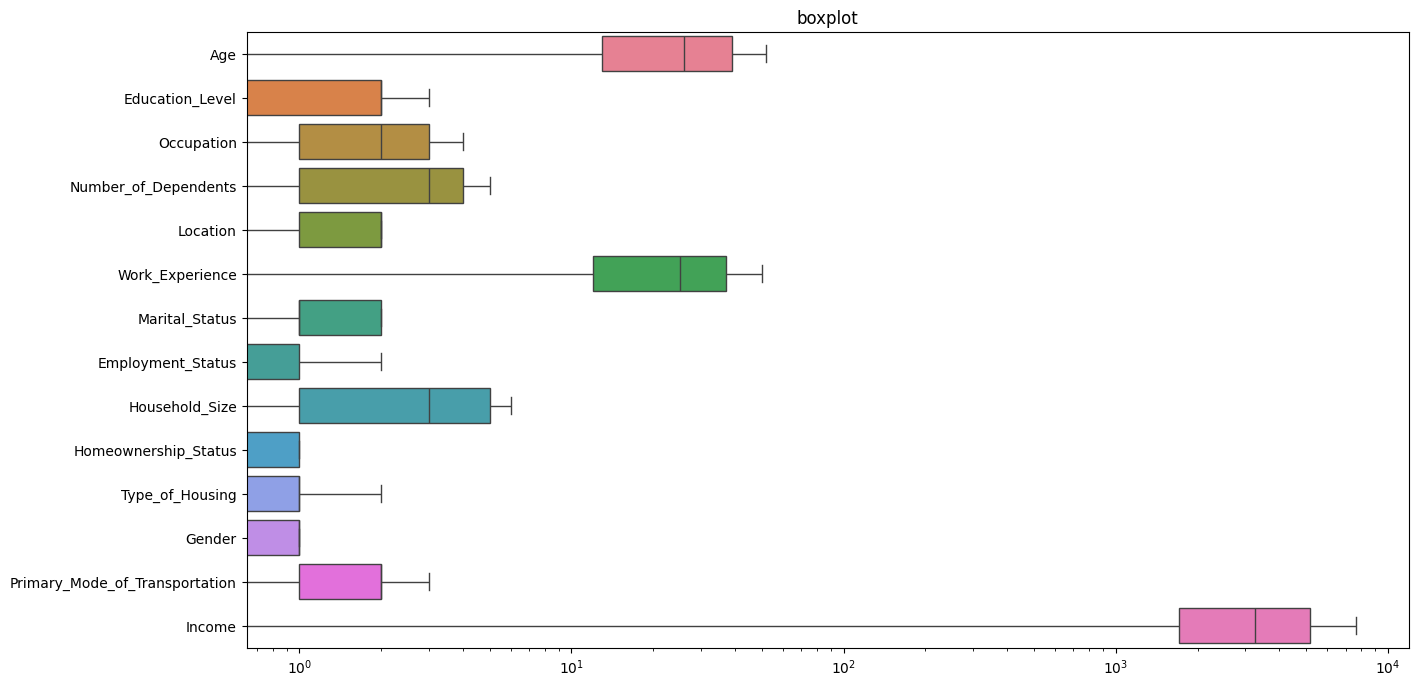

In [246]:
cols = [col for col in df.columns]
plt.figure(figsize=(15, 8))
sns.boxplot(data=df[cols], orient='h')
plt.title('boxplot')
plt.xscale('log')
plt.show()

In [247]:
df.describe()

,Age,Education_Level,Occupation,Number_of_Dependents,Location,Work_Experience,Marital_Status,Employment_Status,Household_Size,Homeownership_Status,Type_of_Housing,Gender,Primary_Mode_of_Transportation,Income
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,26.021700,1.38650,2.178600,2.527000,1.602500,24.858800,1.293600,0.697600,2.989600,0.398200,0.79430,0.512300,1.416100,3475.328200
std,15.203998,1.24309,1.356645,1.713991,0.664784,14.652622,0.632645,0.779112,2.010496,0.489552,0.74313,0.499874,0.914573,2107.089769
min,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,13.000000,0.00000,1.000000,1.000000,1.000000,12.000000,1.000000,0.000000,1.000000,0.000000,0.00000,0.000000,1.000000,1709.000000
50%,26.000000,2.00000,2.000000,3.000000,2.000000,25.000000,1.000000,0.000000,3.000000,0.000000,1.00000,1.000000,2.000000,3255.500000
75%,39.000000,2.00000,3.000000,4.000000,2.000000,37.000000,2.000000,1.000000,5.000000,1.000000,1.00000,1.000000,2.000000,5167.250000
max,52.000000,3.00000,4.000000,5.000000,2.000000,50.000000,2.000000,2.000000,6.000000,1.000000,2.00000,1.000000,3.000000,7666.000000


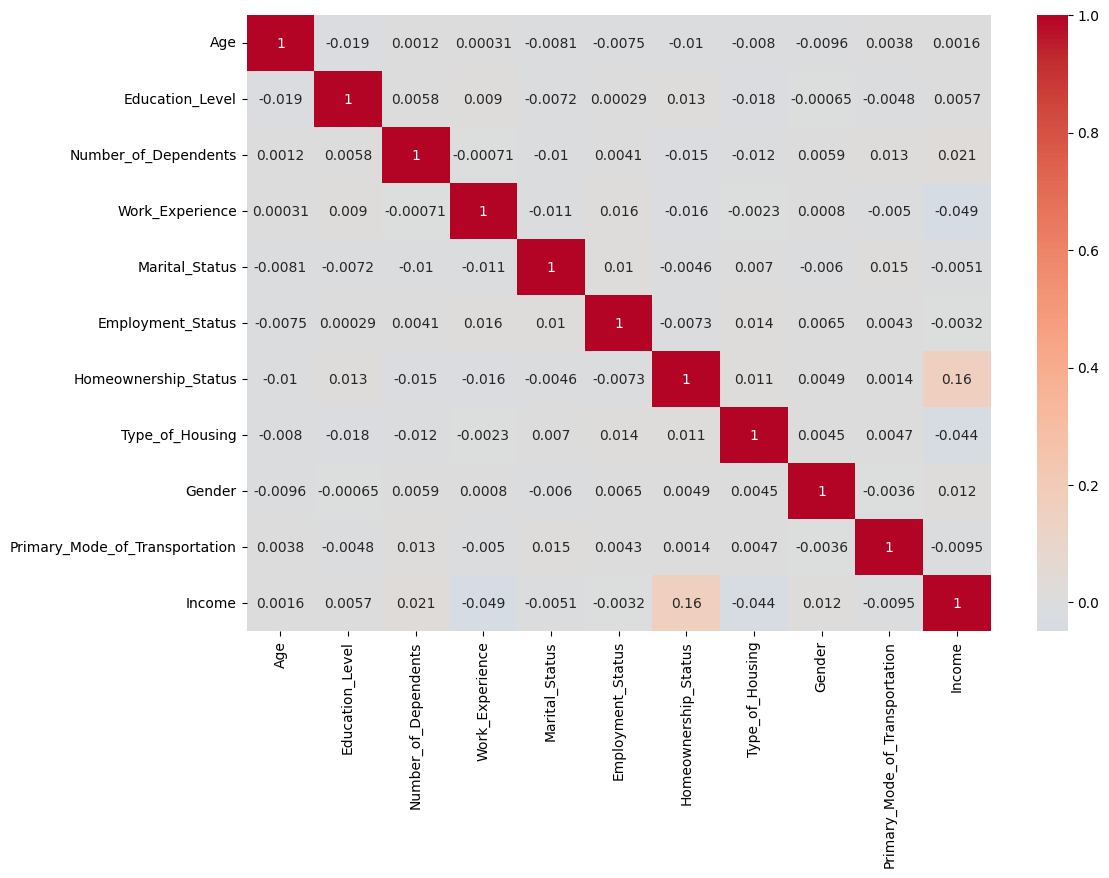

In [248]:
df = df.drop(['Occupation', 'Location', 'Household_Size'], axis=1)
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.show()

In [250]:
features = df.drop(columns=['Income'])
target = df['Income']
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

In [251]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [252]:
model = LinearRegression().fit(X_train, y_train)

In [253]:
model.score(features, target)

0.029336531163741908

In [254]:
y_pred = model.predict(X_test)

In [255]:
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {root_mean_squared_error(y_test, y_pred)}')
print(f'R^2: {r2_score(y_test, y_pred)}')

MAE: 1733.671008911475
MSE: 4302154.714050284
RMSE: 2074.1636179555085
R^2: 0.030376923099706743


In [256]:
lasso = Lasso(alpha=0.1)
model = lasso.fit(X_train_scaled, y_train)

In [257]:
y_pred = model.predict(X_test)

In [258]:
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {root_mean_squared_error(y_test, y_pred)}')
print(f'R^2: {r2_score(y_test, y_pred)}')

MAE: 2941.3221190900513
MSE: 12794075.866185894
RMSE: 3576.8807453123027
R^2: -1.8835390710037485


In [259]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred = rf.predict(X_test)

In [260]:
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {root_mean_squared_error(y_test, y_pred)}')
print(f'R^2: {r2_score(y_test, y_pred)}')

MAE: 2288.587
MSE: 7991091.698
RMSE: 2826.8519059193745
R^2: -0.8010386504004716
